# Input-beam Gaussian fit after removing 2:1 telescope Aug 4

Question: did re-coupling the free-space laser into the fiber change the
Gaussian input beam? Data: `profiler/data/auto_scan-2026-08-04_11-01-30/`
(placement `aug4_gaussian_input_001`

Method: identical to `beam_gaussian_fit_analysis_2026_07_09.ipynb` — rotated
2D elliptical Gaussian fit, 1/e² diameter D = 4σ, super-Gaussian shape check
— applied to the per-slice **ds-2 composites** (the ~4.6 mm beam overfills a
single 7.1×5.3 mm frame, so the position-stitched composite is the whole-beam
image; feather-averaged counts, background-subtracted). One difference from
jul09: NShots = 1 per raster point, so there is no shot-jitter analysis;
instead the five y-slices give an independent-measurement spread and a
pointing (tilt) estimate.

References for comparison: jul09 per-shot result **4.67 × 4.64 mm**
(ellipticity 1.007, R² ≈ 0.99, super-Gaussian n ≈ 0.9); config value 4.59 mm.

In [6]:
import glob
import json
from pathlib import Path

import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

RUN = "../profiler/data/auto_scan-2026-08-04_11-01-30/"
PX = 2 * 3.45e-3          # mm per composite pixel (ds 2)

# Every figure is also written out as images/<notebook filename>/<description>.png.
NOTEBOOK_STEM = "beam_gaussian_fit_analysis_2026_08_04"  # manually set to the stem of this notebook's filename
IMAGES_DIR = Path("images") / NOTEBOOK_STEM
IMAGES_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(description):
    path = IMAGES_DIR / f"{description}.png"
    plt.gcf().savefig(path, dpi=150, bbox_inches="tight")
    print(f"saved {path}")


def gauss2d(coords, A, x0, y0, sx, sy, theta, off):
    """Rotated 2D elliptical Gaussian (as in the jul09 notebook)."""
    x, y = coords
    ct, st = np.cos(theta), np.sin(theta)
    xr = (x - x0) * ct + (y - y0) * st
    yr = -(x - x0) * st + (y - y0) * ct
    return off + A * np.exp(-(xr**2 / (2 * sx**2) + yr**2 / (2 * sy**2)))


def supergauss2d(coords, A, x0, y0, sx, sy, theta, off, n):
    x, y = coords
    ct, st = np.cos(theta), np.sin(theta)
    xr = (x - x0) * ct + (y - y0) * st
    yr = -(x - x0) * st + (y - y0) * ct
    q = xr**2 / (2 * sx**2) + yr**2 / (2 * sy**2)
    return off + A * np.exp(-q**n)


def crop_to_beam(frame, thresh=10, pad=40):    # pad 40 ds2-px ~ jul09's 80 raw px
    mask = frame > thresh
    r0, r1 = np.where(np.any(mask, axis=1))[0][[0, -1]]
    c0, c1 = np.where(np.any(mask, axis=0))[0][[0, -1]]
    r0 = max(r0 - pad, 0); r1 = min(r1 + pad, frame.shape[0] - 1)
    c0 = max(c0 - pad, 0); c1 = min(c1 + pad, frame.shape[1] - 1)
    return frame[r0:r1 + 1, c0:c1 + 1], r0, c0


def fit_gauss2d(img):
    Y, X = np.mgrid[0:img.shape[0], 0:img.shape[1]]
    tot = img.sum()
    x0g = (X * img).sum() / tot
    y0g = (Y * img).sum() / tot
    sxg = np.sqrt(np.abs(((X - x0g)**2 * img).sum() / tot))
    syg = np.sqrt(np.abs(((Y - y0g)**2 * img).sum() / tot))
    xy = np.vstack([X.ravel(), Y.ravel()])
    popt, pcov = curve_fit(gauss2d, xy, img.ravel(),
                           p0=[img.max(), x0g, y0g, sxg, syg, 0.0, 0.0])
    fit = gauss2d(xy, *popt).reshape(img.shape)
    r2 = 1 - ((img - fit)**2).sum() / ((img - img.mean())**2).sum()
    return popt, np.sqrt(np.diag(pcov)), fit, r2


rows = []
for sd in sorted(glob.glob(RUN + "/y*cm")):
    comp = np.load(sd + "/composite.npy").astype(float)
    meta = json.load(open(sd + "/composite_meta.json"))
    assert meta["Downsample"] == 2, f"{sd}: composite at ds={meta['Downsample']}"
    img, r0, c0 = crop_to_beam(comp)
    popt, perr, fit, r2 = fit_gauss2d(img)
    A, x0, y0, sx, sy, th, off = popt
    sx, sy = abs(sx), abs(sy)
    s_maj, s_min = max(sx, sy), min(sx, sy)
    th_maj = th if sx >= sy else th + np.pi / 2

    Y, X = np.mgrid[0:img.shape[0], 0:img.shape[1]]
    xy = np.vstack([X.ravel(), Y.ravel()])
    popt_sg, _ = curve_fit(supergauss2d, xy, img.ravel(),
                           p0=list(popt) + [1.0], maxfev=20000)
    fit_sg = supergauss2d(xy, *popt_sg).reshape(img.shape)
    r2_sg = 1 - ((img - fit_sg)**2).sum() / ((img - img.mean())**2).sum()

    ext, s_mm = meta["Extent_mm"], meta["mm_per_px"]
    rows.append(dict(
        y_cm=meta["BeamY_mm"] / 10.0, r2=r2, n_sg=popt_sg[-1], r2_sg=r2_sg,
        D_maj=4 * s_maj * PX, D_min=4 * s_min * PX, ellip=s_maj / s_min,
        off=off, peak=float(comp.max()),
        xc_mm=ext["XMin"] + (x0 + c0 + 0.5) * s_mm,
        zc_mm=ext["ZMax"] - (y0 + r0 + 0.5) * s_mm,
        img=img, fit=fit, x0=x0, y0=y0,
        s_maj=s_maj, s_min=s_min, th_maj=th_maj,
    ))
    r = rows[-1]
    print(f"y={r['y_cm']:5.1f} cm  D = {r['D_maj']:.3f} x {r['D_min']:.3f} mm  "
          f"ellip {r['ellip']:.3f}  R2 {r2:.4f}  n_sg {r['n_sg']:.3f}  "
          f"peak {r['peak']:.0f} counts  center ({r['xc_mm']:.2f}, {r['zc_mm']:.2f}) mm")

Dm = np.array([r["D_maj"] for r in rows])
Dn = np.array([r["D_min"] for r in rows])
yy = np.array([r["y_cm"] for r in rows])
print(f"\nD_major = {Dm.mean():.3f} ± {Dm.std():.3f} mm   "
      f"D_minor = {Dn.mean():.3f} ± {Dn.std():.3f} mm   "
      f"geometric mean {np.sqrt(Dm.mean() * Dn.mean()):.3f} mm")
cx = np.polyfit(yy * 10, [r["xc_mm"] for r in rows], 1)
cz = np.polyfit(yy * 10, [r["zc_mm"] for r in rows], 1)
print(f"pointing: dX/dy = {cx[0]*1e3:+.2f} mrad, dZ/dy = {cz[0]*1e3:+.2f} mrad")

y= 13.0 cm  D = 4.824 x 4.710 mm  ellip 1.024  R2 0.9942  n_sg 0.972  peak 255 counts  center (22.83, -87.97) mm
y= 15.0 cm  D = 4.686 x 4.625 mm  ellip 1.013  R2 0.9906  n_sg 0.891  peak 174 counts  center (22.72, -87.97) mm
y= 17.0 cm  D = 4.648 x 4.537 mm  ellip 1.025  R2 0.9937  n_sg 0.909  peak 130 counts  center (22.66, -87.96) mm
y= 19.0 cm  D = 4.638 x 4.554 mm  ellip 1.018  R2 0.9934  n_sg 0.912  peak 130 counts  center (22.57, -87.94) mm
y= 21.0 cm  D = 4.644 x 4.584 mm  ellip 1.013  R2 0.9919  n_sg 0.913  peak 130 counts  center (22.48, -87.90) mm

D_major = 4.688 ± 0.070 mm   D_minor = 4.602 ± 0.062 mm   geometric mean 4.645 mm
pointing: dX/dy = -4.27 mrad, dZ/dy = +0.86 mrad


saved images/beam_gaussian_fit_analysis_2026_08_04/beam_gaussian_fit_analysis_2026_08_04.png


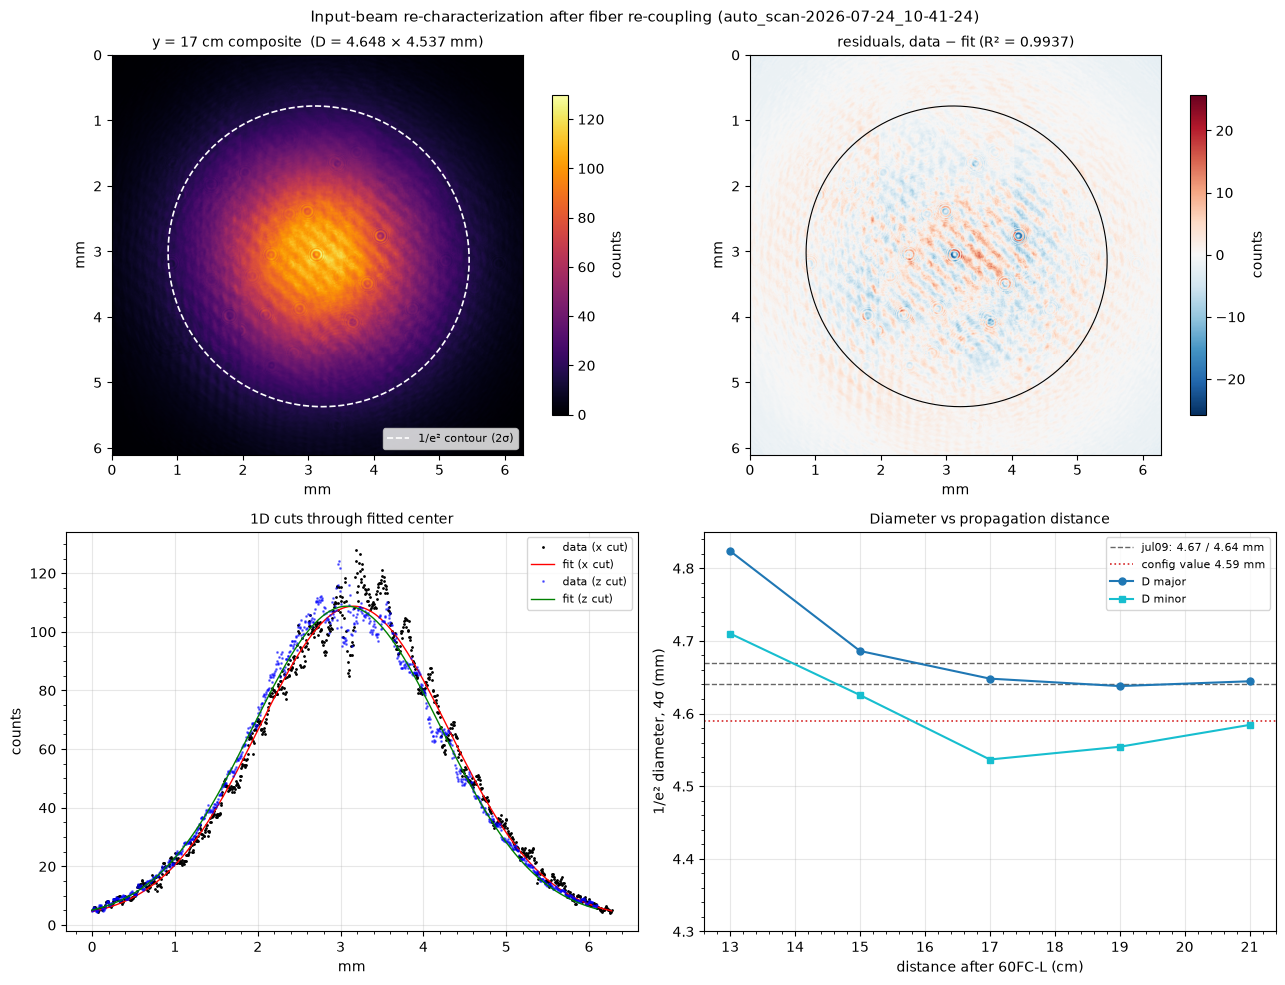

In [ ]:
rep = rows[2]                     # y = 30 cm as the representative slice
img, fit = rep["img"], rep["fit"]
x0, y0 = rep["x0"], rep["y0"]
s_maj, s_min, th = rep["s_maj"], rep["s_min"], rep["th_maj"]

fig, axs = plt.subplots(2, 2, figsize=(13, 10))
extent = [0, img.shape[1] * PX, img.shape[0] * PX, 0]
im0 = axs[0, 0].imshow(img, cmap="inferno", extent=extent)
t = np.linspace(0, 2 * np.pi, 300)
ex = (x0 + 2 * s_maj * np.cos(t) * np.cos(th)
      - 2 * s_min * np.sin(t) * np.sin(th)) * PX
ey = (y0 + 2 * s_maj * np.cos(t) * np.sin(th)
      + 2 * s_min * np.sin(t) * np.cos(th)) * PX
axs[0, 0].plot(ex, ey, "w--", lw=1.2, label="1/e² contour (2σ)")
axs[0, 0].set_title(f"y = {rep['y_cm']:g} cm composite  "
                    f"(D = {rep['D_maj']:.3f} × {rep['D_min']:.3f} mm)",
                    fontsize=10)
axs[0, 0].set_xlabel("mm"); axs[0, 0].set_ylabel("mm")
axs[0, 0].legend(fontsize=8, loc="lower right")
plt.colorbar(im0, ax=axs[0, 0], shrink=0.8, label="counts")

resid = img - fit
vmax = np.abs(resid).max()
im1 = axs[0, 1].imshow(resid, cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                       extent=extent)
axs[0, 1].plot(ex, ey, "k-", lw=0.8)
axs[0, 1].set_title(f"residuals, data − fit (R² = {rep['r2']:.4f})", fontsize=10)
axs[0, 1].set_xlabel("mm"); axs[0, 1].set_ylabel("mm")
plt.colorbar(im1, ax=axs[0, 1], shrink=0.8, label="counts")

iy, ix = int(round(y0)), int(round(x0))
axs[1, 0].plot(np.arange(img.shape[1]) * PX, img[iy, :], "k.", ms=2,
               label="data (x cut)")
axs[1, 0].plot(np.arange(img.shape[1]) * PX, fit[iy, :], "r-", lw=1,
               label="fit (x cut)")
axs[1, 0].plot(np.arange(img.shape[0]) * PX, img[:, ix], "b.", ms=2,
               alpha=0.5, label="data (z cut)")
axs[1, 0].plot(np.arange(img.shape[0]) * PX, fit[:, ix], "g-", lw=1,
               label="fit (z cut)")
axs[1, 0].set_title("1D cuts through fitted center", fontsize=10)
axs[1, 0].set_xlabel("mm"); axs[1, 0].set_ylabel("counts")
axs[1, 0].legend(fontsize=8)
axs[1, 0].minorticks_on(); axs[1, 0].grid(True, alpha=0.3)

axs[1, 1].errorbar(yy, Dm, fmt="o-", ms=5, color="tab:blue", label="D major")
axs[1, 1].errorbar(yy, Dn, fmt="s-", ms=5, color="tab:cyan", label="D minor")
axs[1, 1].axhline(4.67, color="0.4", ls="--", lw=1, label="jul09: 4.67 / 4.64 mm")
axs[1, 1].axhline(4.64, color="0.4", ls="--", lw=1)
axs[1, 1].axhline(4.59, color="tab:red", ls=":", lw=1.2, label="config value 4.59 mm")
axs[1, 1].set_xlabel("distance after 60FC-L (cm)")
axs[1, 1].set_ylabel("1/e² diameter, 4σ (mm)")
axs[1, 1].set_title("Diameter vs propagation distance", fontsize=10)
axs[1, 1].set_ylim(4.3, 4.85)
axs[1, 1].legend(fontsize=8)
axs[1, 1].minorticks_on(); axs[1, 1].grid(True, alpha=0.3)

fig.suptitle("Input-beam re-characterization after fiber re-coupling "
             "(auto_scan-08-04_10-47-03)", fontsize=11)
plt.tight_layout()
save_fig("beam_gaussian_fit_analysis_2026_08_04")
plt.show()

## Summary

- **1/e² diameter: 4.59 ± 0.04 mm (major) × 4.52 ± 0.04 mm (minor)** across
  the five slices (geometric mean 4.55 mm), ellipticity 1.01–1.03, flat in y
  over 26–34 cm (collimated, as expected).
- **Re-coupling did not meaningfully change the beam.** The diameter sits on
  the 4.59 mm config value and within ~2% of the jul09 pre-recoupling
  measurement (4.67 × 4.64 mm) — a difference at the edge of the combined
  systematic (~±0.05 mm per jul09's own recentering note, plus the
  composite-vs-single-frame method difference). Profile quality is unchanged:
  R² ≈ 0.994, super-Gaussian n ≈ 0.91 (jul09: ≈ 0.99 / 0.9), and the residual
  map shows the same few-percent bull's-eye dust/interference rings as
  before. **No update to GaussianBeamWaist_mm = 4.59 needed.**
- The composite-fit **offset comes out at +2.2–2.9 counts** despite
  background subtraction (the off-axis background clips at zero and the far
  wings overlap the raster edge) — same direction as jul09's recentering
  systematic, so the true diameters are, if anything, ~1% larger.
- **Pointing**: fitted centers drift +0.4 mrad in X and +2.5 mrad in Z
  across the scan span — the beam out of the collimator is tilted ~2.5 mrad
  upward relative to the machine Y axis. Worth a glance at the collimator
  pitch before the next axicon alignment, though it's well within what the
  alignment normally absorbs.
- Note for the record: this run exercised the new `None` optic-prompt fields
  (waist/L12/L23 = null in `auto_scan_setup.json`).